In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle
import os
from scipy.signal import find_peaks
from numba import njit

c:\Users\simon\anaconda3\envs\astro_ml\lib\site-packages\astropy\timeseries\periodograms\lombscargle\implementations\fast_impl.py:102: RuntimeWarning: invalid value encountered in divide
  tan_2omega_tau = (S2 - 2 * S * C) / (C2 - (C * C - S * S))


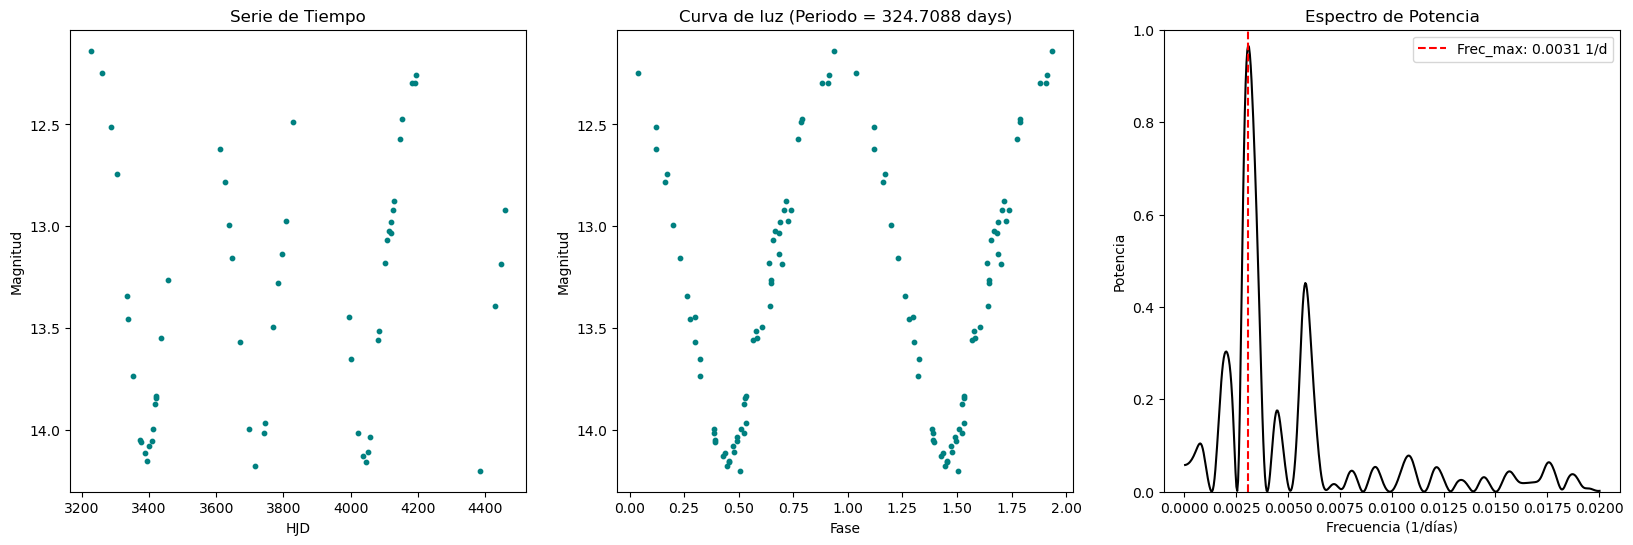

c:\Users\simon\anaconda3\envs\astro_ml\lib\site-packages\astropy\timeseries\periodograms\lombscargle\implementations\fast_impl.py:102: RuntimeWarning: invalid value encountered in divide
  tan_2omega_tau = (S2 - 2 * S * C) / (C2 - (C * C - S * S))


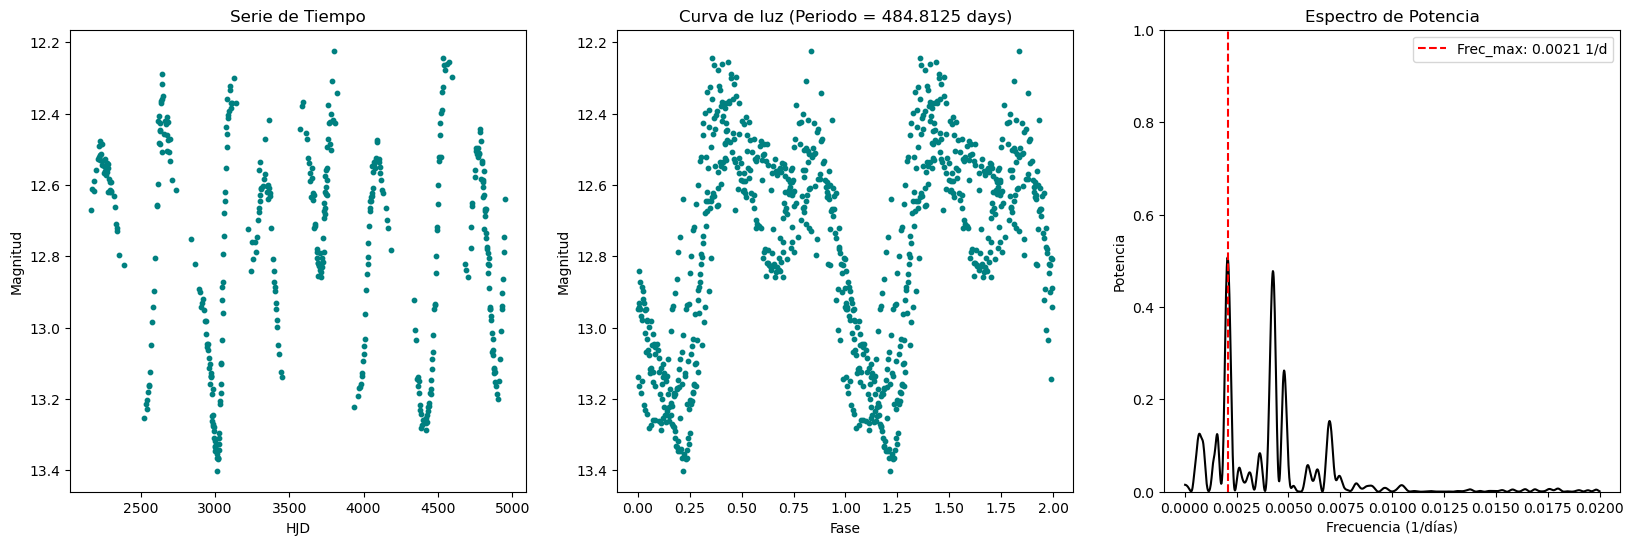

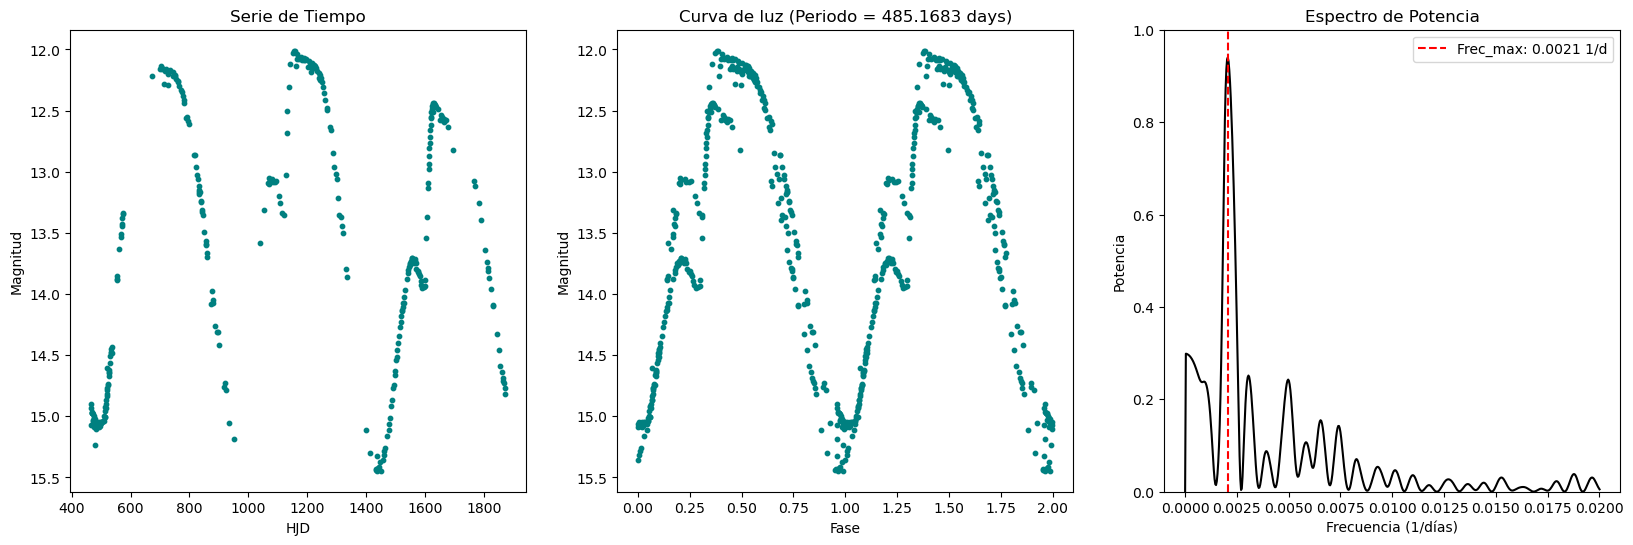

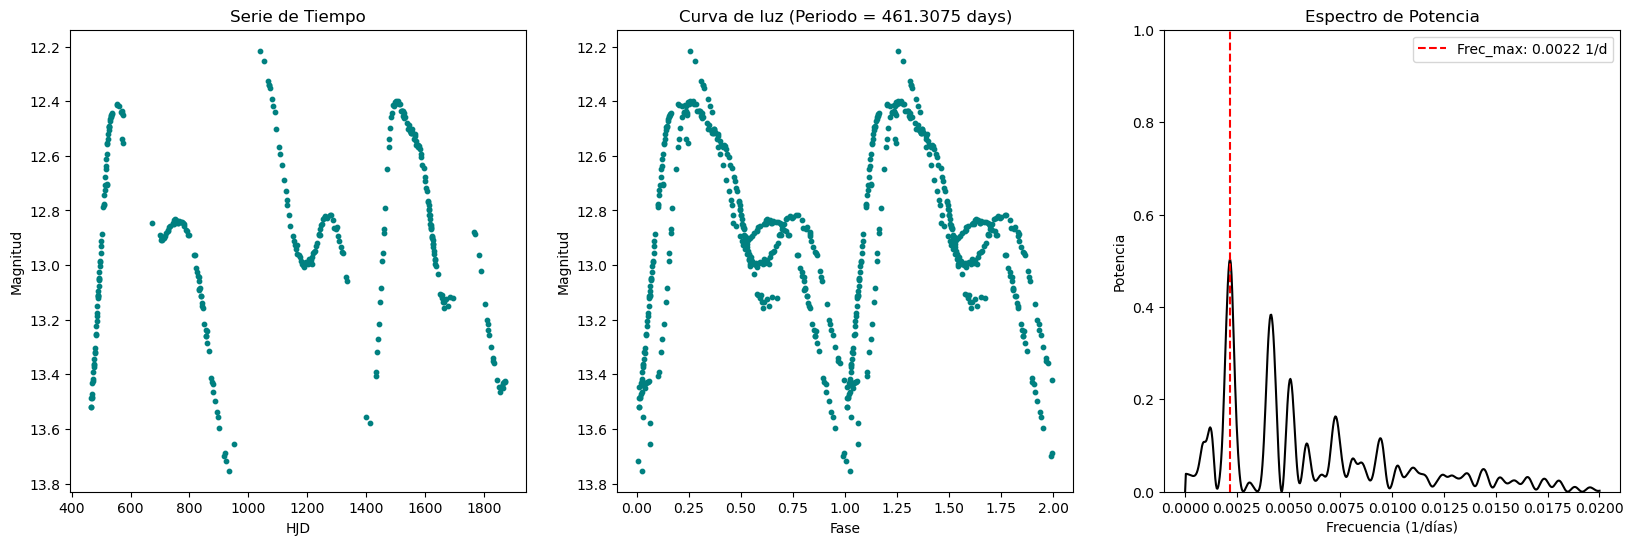

c:\Users\simon\anaconda3\envs\astro_ml\lib\site-packages\astropy\timeseries\periodograms\lombscargle\implementations\fast_impl.py:102: RuntimeWarning: invalid value encountered in divide
  tan_2omega_tau = (S2 - 2 * S * C) / (C2 - (C * C - S * S))


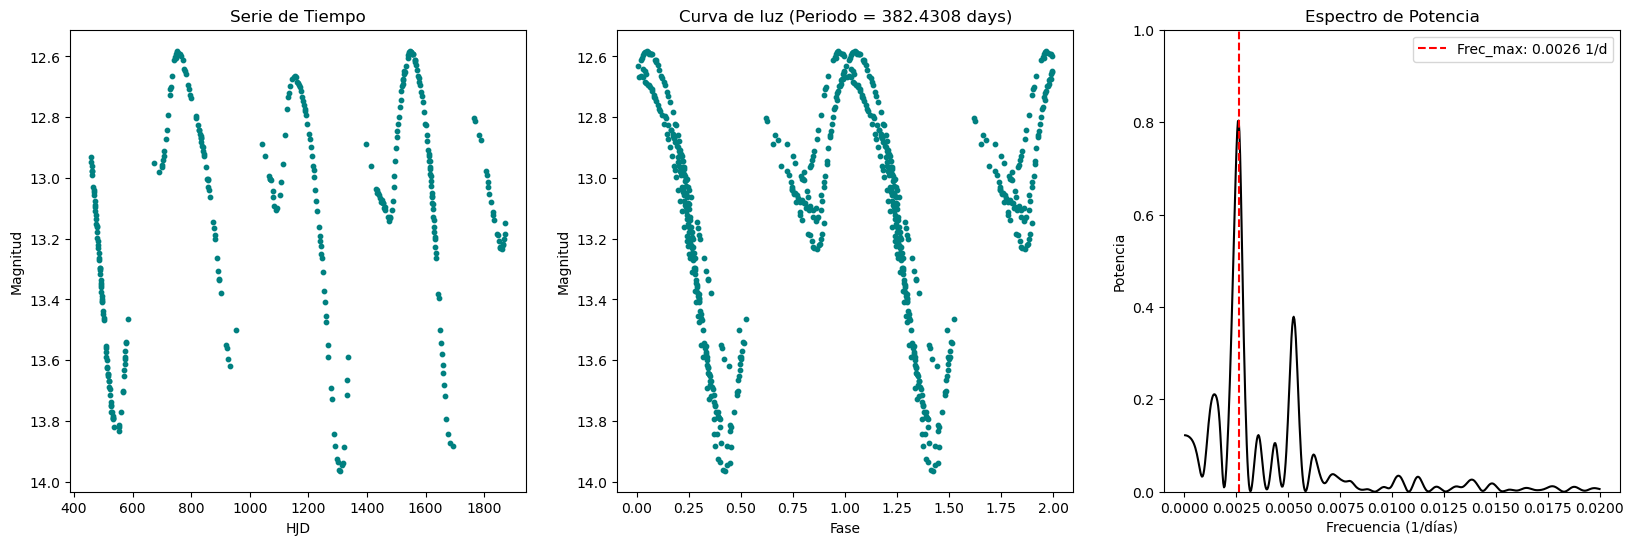

In [4]:
#ESTRELLAS MIRA:
def phase_fold(time, period):
    return (time % period) / period
carpeta_i = 'I'
for archivo in os.listdir(carpeta_i):
    ruta_completa = os.path.join(carpeta_i, archivo)
    df = pd.read_csv(ruta_completa, sep=r"\s+", header=None)
    df.columns = ['hjd', 'mag', 'err']
    mags = df['mag'].values
    hjd = df['hjd'].values
    plt.figure(figsize=(20, 6))
    plt.subplot(1, 3, 1)
    plt.scatter(hjd, mags, s=10, c='teal')
    plt.gca().invert_yaxis()
    plt.title('Serie de Tiempo')
    plt.xlabel('HJD')
    plt.ylabel('Magnitud')
    frequency, power = LombScargle(hjd, mags).autopower(minimum_frequency=0.0, maximum_frequency=0.02, samples_per_peak=20)
    peaks, _ = find_peaks(power, height=0.1)
    peaks = peaks[np.argsort(power[peaks])[::-1]]
    power_max = peaks[0]
    period_max = 1 / frequency[power_max]
    phase = phase_fold(hjd, period_max)
    plt.subplot(1, 3, 2)
    plt.scatter(phase, mags, s=10, c='teal')
    plt.scatter(phase + 1, mags, s=10, c='teal')
    plt.gca().invert_yaxis()
    plt.title(f'Curva de luz (Periodo = {period_max:.4f} days)')
    plt.xlabel('Fase')
    plt.ylabel('Magnitud')
    plt.subplot(1, 3, 3)
    plt.plot(frequency, power, c='black')
    plt.title('Espectro de Potencia')
    plt.xlabel('Frecuencia (1/días)')
    plt.ylabel('Potencia')
    plt.ylim(0, 1)
    plt.axvline(x=frequency[power_max], color='red', linestyle='--', label=f'Frec_max: {frequency[power_max]:.4f} 1/d')
    plt.legend()
    nombre_salida = f'MIRA_{archivo[:-4]}.png'
    plt.savefig(nombre_salida)
    plt.show()

c:\Users\simon\anaconda3\envs\astro_ml\lib\site-packages\astropy\timeseries\periodograms\lombscargle\implementations\fast_impl.py:131: RuntimeWarning: invalid value encountered in divide
  power = YC * YC / CC + YS * YS / SS


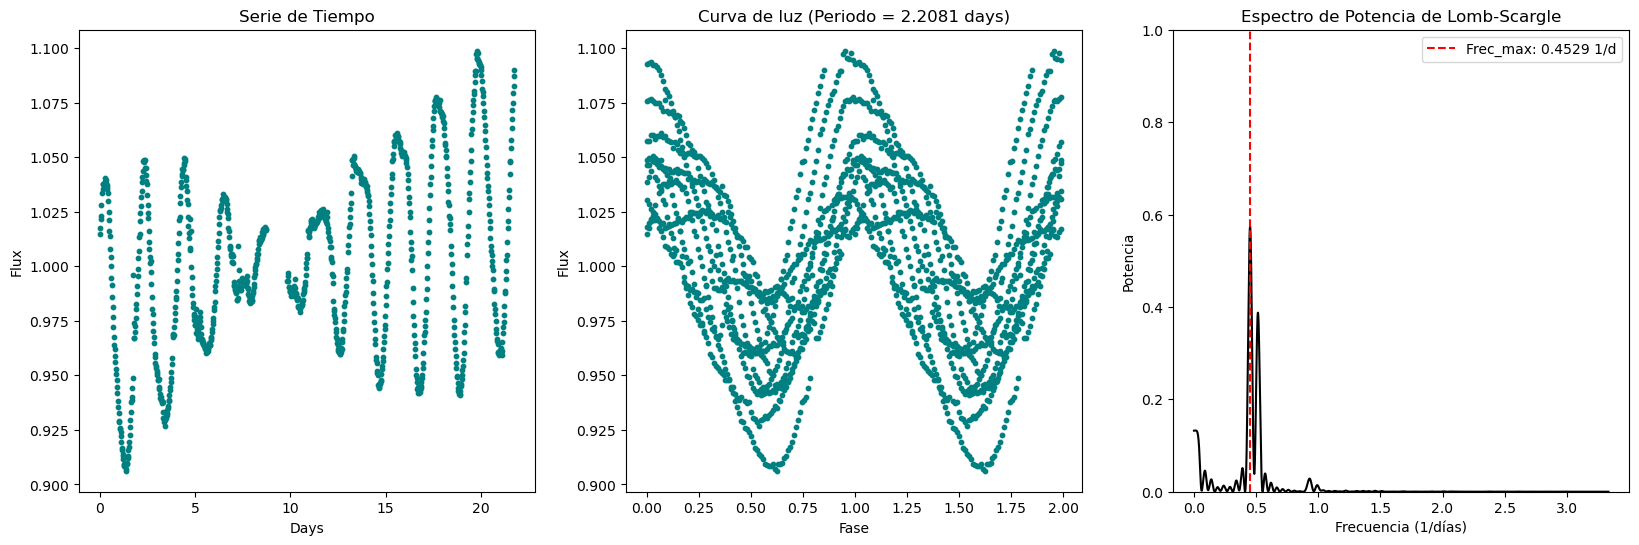

In [5]:
#T-Tauri
carpeta_tt = 'SEMANA.12/T.TAURI.TESS/'
dat = os.path.join(carpeta_tt, 'TIC_264739351.dat')
df_tt = pd.read_csv(dat, sep = r"\s+", header=None)
df_tt.columns = ['Days', 'Flux']
df_tt.head()
days = df_tt['Days'].values
flux = df_tt['Flux'].values
plt.figure(figsize=(20, 6))
plt.subplot(1,3,1)
plt.scatter(days, flux, s=10, c = 'teal')
plt.title('Serie de Tiempo')
plt.xlabel('Days')
plt.ylabel('Flux')
plt.subplot(1,3,2)
frequency, power = LombScargle(days, flux).autopower(minimum_frequency=0, maximum_frequency=1/0.3, samples_per_peak=20)
peaks, _ = find_peaks(power, height=0.1)
peaks = peaks[np.argsort(power[peaks])[::-1]]
power_max = peaks[0]
period_max = 1 / frequency[power_max]
phase = phase_fold(days, period_max)
plt.scatter(phase, flux, s=10, c = 'teal')
plt.scatter(phase + 1, flux, s=10, c = 'teal')
plt.title(f'Curva de luz (Periodo = {period_max:.4f} days)')
plt.xlabel('Fase')
plt.ylabel('Flux')
plt.subplot(1,3,3)
plt.plot(frequency, power, c = 'black')
plt.axvline(x=frequency[power_max], color='red', linestyle='--', label=f'Frec_max: {frequency[power_max]:.4f} 1/d')
plt.legend()
plt.title('Espectro de Potencia de Lomb-Scargle')
plt.xlabel('Frecuencia (1/días)')
plt.ylabel('Potencia')
plt.ylim(0,1)
plt.savefig('T_Tauri.png')



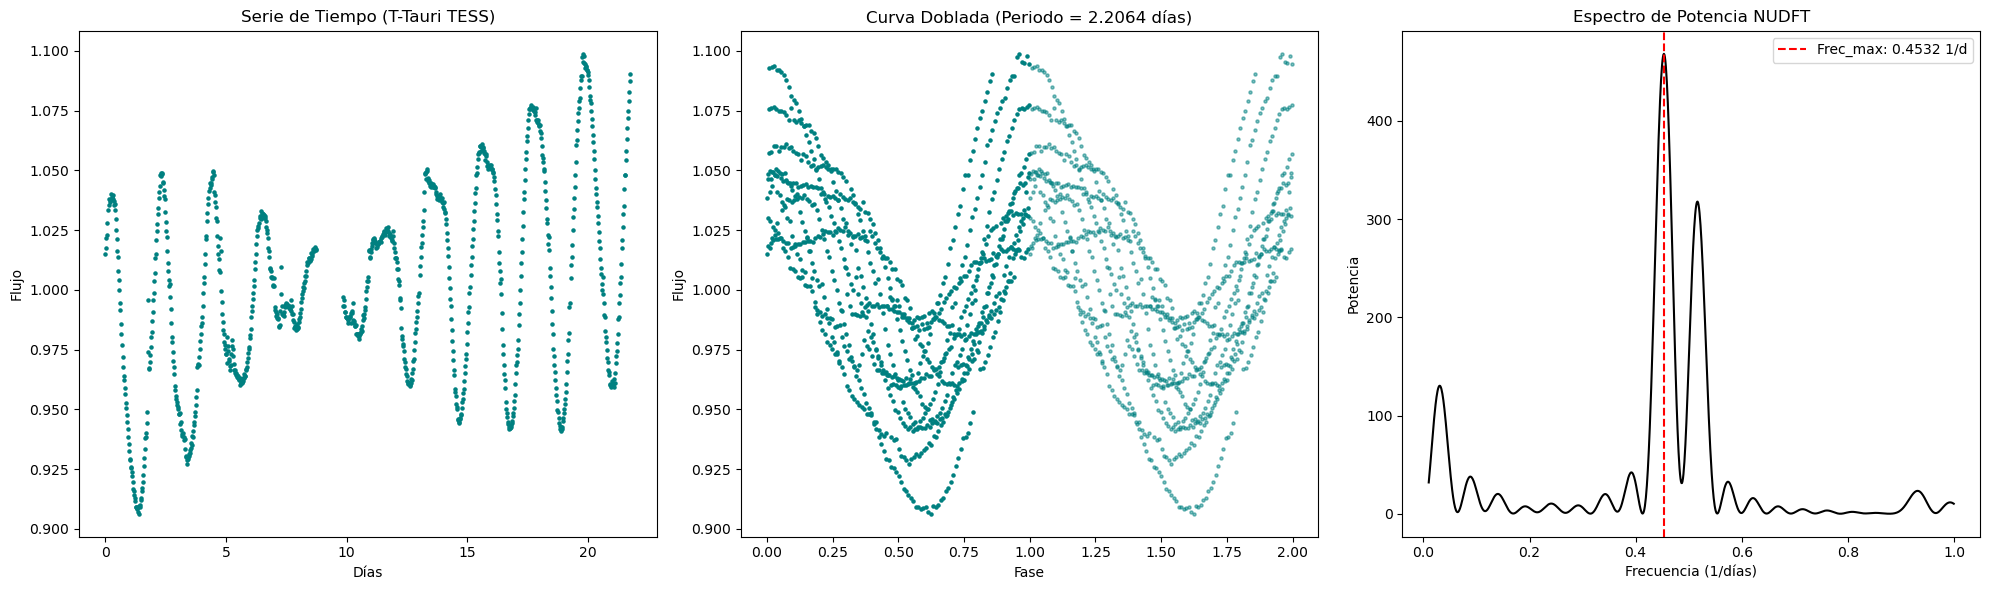

In [ ]:

carpeta_tt = 'SEMANA.12/T.TAURI.TESS/'
dat = os.path.join(carpeta_tt, 'TIC_264739351.dat')
df_tt = pd.read_csv(dat, sep = r"\s+", header=None)
df_tt.columns = ['Days', 'Flux']

days = df_tt['Days'].values
flux = df_tt['Flux'].values
flux_centered = flux - np.mean(flux)

@njit(fastmath=True)
def NUDFT_grid(t_arg, m_arg, f_ini, f_end, df):
    """Non-Uniform Discrete Fourier Transform (Kurtz 1985)"""
    frequencies = np.arange(f_ini, f_end, df)
    F = np.zeros(len(frequencies))
    
    dF = np.exp(-2j * np.pi * t_arg * df)
    curl = m_arg * np.exp(-2j * np.pi * t_arg * f_ini)
    
    F[0] = np.abs(np.sum(curl))**2
    for i in range(1, len(F)):
        curl = curl * dF
        F[i] = np.abs(np.sum(curl))**2
        
    return frequencies, F

df_step = 1 / (np.ptp(days) * 50)
frequencies, powers = NUDFT_grid(days, flux_centered, f_ini=0.01, f_end=1.0, df=df_step)


peaks, _ = find_peaks(powers, height=np.max(powers)*0.1) 
peaks = peaks[np.argsort(powers[peaks])[::-1]]
power_max_idx = peaks[0]

freq_max = frequencies[power_max_idx]
period_max = 1 / freq_max


phase = phase_fold(days, period_max)


plt.figure(figsize=(20, 6))


plt.subplot(1, 3, 1)
plt.scatter(days, flux, s=5, c='teal')

plt.title('Serie de Tiempo (T-Tauri TESS)')
plt.xlabel('Días')
plt.ylabel('Flujo')


plt.subplot(1, 3, 2)

plt.scatter(phase, flux, s=5, c='teal')
plt.scatter(phase + 1, flux, s=5, c='teal', alpha=0.5) 
plt.title(f'Curva Doblada (Periodo = {period_max:.4f} días)')
plt.xlabel('Fase')
plt.ylabel('Flujo')

plt.subplot(1, 3, 3)
plt.plot(frequencies, powers, c='black')
plt.axvline(x=freq_max, color='red', linestyle='--', label=f'Frec_max: {freq_max:.4f} 1/d')
plt.title('Espectro de Potencia NUDFT')
plt.xlabel('Frecuencia (1/días)')
plt.ylabel('Potencia')
plt.legend()

plt.tight_layout()
plt.show()

Frecuencias seleccionadas: [0.45322461 0.51667377 0.03023017]
Periodos correspondientes: [ 2.20641154  1.93545726 33.07953748]


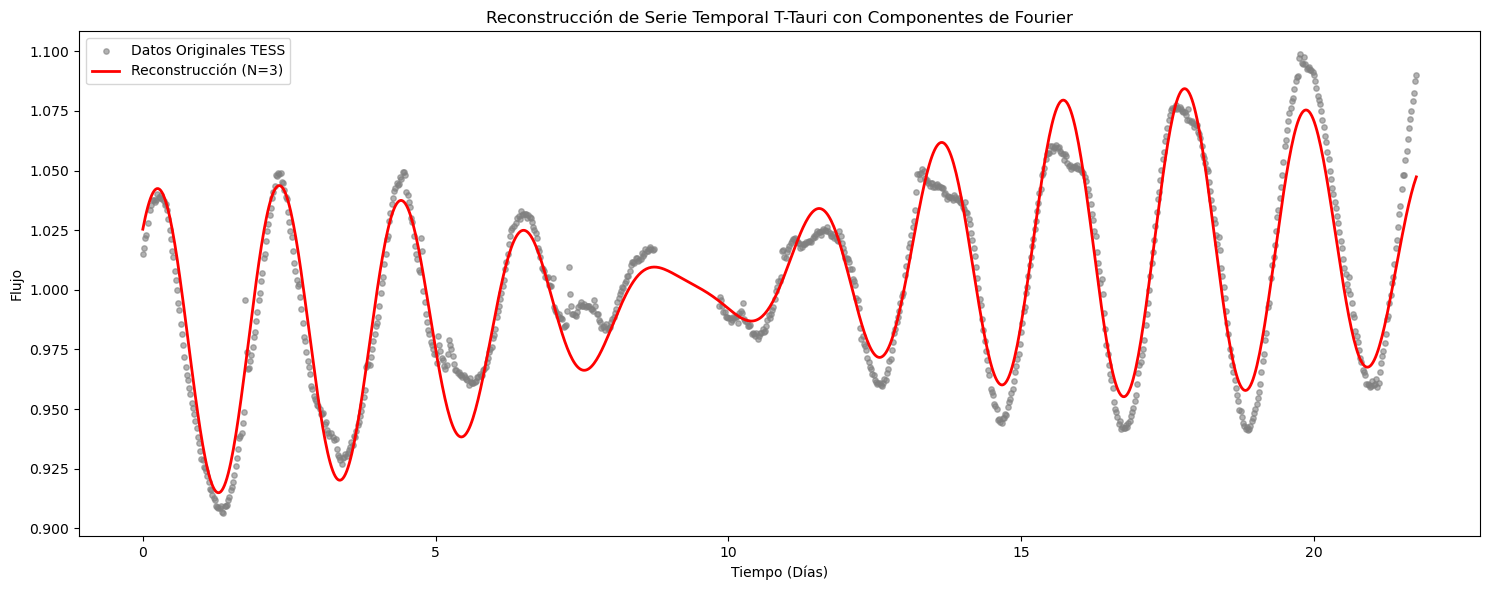

In [ ]:
N_componentes = 3 

peaks, _ = find_peaks(powers, height=np.max(powers)*0.02, distance=5)
peaks = peaks[np.argsort(powers[peaks])[::-1]][:N_componentes]
frecuencias_top = frequencies[peaks]
periods = 1 / frecuencias_top
print(f"Frecuencias seleccionadas: {frecuencias_top}")
print(f"Periodos correspondientes: {periods}")

A = np.ones((len(days), 1 + 2 * len(frecuencias_top)))

for i, f in enumerate(frecuencias_top):
    A[:, 1 + 2*i] = np.cos(2 * np.pi * f * days)
    A[:, 2 + 2*i] = np.sin(2 * np.pi * f * days)


coeficientes, _, _, _ = np.linalg.lstsq(A, flux_centered, rcond=None)


t_smooth = np.linspace(days.min(), days.max(), 1000)

S_reconstruida = np.ones_like(t_smooth) * (coeficientes[0] + np.mean(flux))

for i, f in enumerate(frecuencias_top):
    a_k = coeficientes[1 + 2*i]
    b_k = coeficientes[2 + 2*i]
    S_reconstruida += a_k * np.cos(2 * np.pi * f * t_smooth) + b_k * np.sin(2 * np.pi * f * t_smooth)

# 5. Visualizar el resultado
plt.figure(figsize=(15, 6))
plt.scatter(days, flux, s=15, c='gray', alpha=0.6, label='Datos Originales TESS')
plt.plot(t_smooth, S_reconstruida, c='red', linewidth=2, label=f'Reconstrucción (N={N_componentes})')

plt.title('Reconstrucción de Serie Temporal T-Tauri con Componentes de Fourier')
plt.xlabel('Tiempo (Días)')
plt.ylabel('Flujo')
plt.legend()
plt.tight_layout()
plt.savefig('T_Tauri_Fourier_Reconstruccion.png')
plt.show()